In [1]:
import os
import shutil
import json
from collections import Counter

os.environ["CUDA_VISIBLE_DEVICES"] = "2"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

In [2]:
import logging

loggers = [logging.getLogger(name) for name in logging.root.manager.loggerDict]
for logger in loggers:
    if "transformers" in logger.name.lower():
        logger.setLevel(logging.ERROR)

In [3]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    RichProgressBar,
    ModelCheckpoint,
    EarlyStopping,
)
import numpy as np
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt
import torch
import torchmetrics
import seaborn as sns

In [4]:
from models.models import LitXLMRobertaModel
from models.data import ArabicSocialMediaDataModule

# Multi-Class Detection Experiments - Arabic Social Media Dataset

This notebook implements standardized multi-class detection experiments with save/load functionality and multiple runs support.

In [5]:
class MultiClassExperiment:
    def __init__(self, max_epochs=100, results_file=None, num_runs=10):
        self.max_epochs = max_epochs
        self.num_runs = num_runs
        self.results_file = results_file or "notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/multiclass_results.json"
        self.checkpoint_path = "trained_detectors/Arabic/ArabicSocialMediaDataset/MultiClassAIDetector/checkpoints"
        
        # Initialize data module to get number of classes
        self.data_module = ArabicSocialMediaDataModule(multi_label=True)
        self.data_module.setup()
        self.num_classes = len(set(self.data_module.labels))
        self.class_labels = ['Human', 'Allam', 'Jais', 'Llama', 'OpenAI']
        
        # Load existing results
        self.all_results = self._load_results()
        
        print(f"Initialized MultiClassExperiment with {self.num_runs} runs")
        print(f"Number of classes: {self.num_classes}")
        print(f"Results will be saved to: {self.results_file}")
        
        # Check class distribution
        self._show_class_distribution()
        
    def _load_results(self):
        """Load existing results from JSON file."""
        if os.path.exists(self.results_file):
            print(f"Loading existing results from {self.results_file}")
            with open(self.results_file, 'r') as f:
                return json.load(f)
        else:
            print(f"No existing results found. Starting fresh.")
            return {'runs': []}
    
    def _save_results(self):
        """Save current results to JSON file."""
        with open(self.results_file, 'w') as f:
            json.dump(self.all_results, f, indent=2)
        print(f"Results saved to {self.results_file}")
    
    def _show_class_distribution(self):
        """Show class distribution in train, val, and test sets."""
        train_dist = Counter([sample[1] for sample in list(self.data_module.train_dataset)])
        val_dist = Counter([sample[1] for sample in list(self.data_module.val_dataset)])
        test_dist = Counter([sample[1] for sample in list(self.data_module.test_dataset)])
        
        print(f"\nClass Distribution:")
        print(f"Train: {dict(train_dist)}")
        print(f"Val:   {dict(val_dist)}")
        print(f"Test:  {dict(test_dist)}")
    
    def _get_callbacks(self, run_number):
        """Get callbacks for training."""
        early_stopping = EarlyStopping(
            monitor="val_loss",
            min_delta=0.0,
            patience=3,
            verbose=True,
            mode="min",
        )
        
        checkpoint_dir = f"{self.checkpoint_path}/run_{run_number}"
        checkpoint = ModelCheckpoint(
            monitor="val_loss",
            dirpath=checkpoint_dir,
            filename="best-checkpoint",
            save_top_k=1,
            mode="min",
        )
        
        return [early_stopping, checkpoint], checkpoint_dir
    
    def run_single_experiment(self, run_number):
        """Run a single multi-class experiment."""
        print(f"\n{'='*60}")
        print(f"Running Multi-Class Experiment - Run {run_number + 1}/{self.num_runs}")
        print(f"{'='*60}")
        
        # Initialize model
        model = LitXLMRobertaModel(num_labels=self.num_classes)
        
        # Setup callbacks
        callbacks, checkpoint_dir = self._get_callbacks(run_number)
        
        # Initialize trainer
        trainer = pl.Trainer(
            devices=1,
            max_epochs=self.max_epochs,
            accelerator="auto",
            val_check_interval=0.25,
            check_val_every_n_epoch=1,
            callbacks=callbacks,
        )
        
        # Train the model
        print("Training multi-class model...")
        model.train()
        trainer.fit(model, datamodule=self.data_module)
        print(f"Training completed. Checkpoint saved to: {checkpoint_dir}")
        
        # Load best model and test
        print("Loading best model and testing...")
        model = model.__class__.load_from_checkpoint(
            f"{checkpoint_dir}/best-checkpoint.ckpt",
            confusion_matrix_on_testing=True
        )
        
        # Test the model
        model.eval()
        test_results = trainer.test(model, datamodule=self.data_module)[0]
        
        # Generate predictions for confusion matrix
        predictions_results = trainer.predict(
            model=model,
            dataloaders=self.data_module.test_dataloader(),
            ckpt_path=f"{checkpoint_dir}/best-checkpoint.ckpt",
        )
        
        # Process predictions
        predictions, labels = [], []
        for batch_predictions_outputs in predictions_results:
            predictions.extend(batch_predictions_outputs['predictions'])
            labels.extend(batch_predictions_outputs['labels'])
        
        predictions = torch.tensor(predictions)
        labels = torch.tensor(labels)
        
        # Generate confusion matrix
        confmat = torchmetrics.ConfusionMatrix(
            task="multiclass",
            num_classes=len(set(labels.tolist())),
        )(predictions, labels)
        
        # Compile results
        results = {
            'run_number': run_number,
            'accuracy': test_results['test_acc'],
            'precision': test_results['test_precision'],
            'recall': test_results['test_recall'],
            'f1': test_results['test_f1'],
            'loss': test_results['test_loss'],
            'predictions': predictions.tolist(),
            'labels': labels.tolist(),
            'confusion_matrix': confmat.tolist(),
        }
        
        print(f"Test Results:")
        print(f"  Accuracy:  {results['accuracy']:.4f}")
        print(f"  Precision: {results['precision']:.4f}")
        print(f"  Recall:    {results['recall']:.4f}")
        print(f"  F1-Score:  {results['f1']:.4f}")
        print(f"  Loss:      {results['loss']:.4f}")
        
        # Clean up checkpoints to save space
        shutil.rmtree(checkpoint_dir, ignore_errors=True)
        
        return results
    
    def run_all_experiments(self):
        """Run all experiments with smart resume capability."""
        completed_runs = len(self.all_results['runs'])
        
        print(f"Progress: {completed_runs}/{self.num_runs} experiments completed")
        
        if completed_runs >= self.num_runs:
            print(f"All {self.num_runs} runs already completed!")
            return self.all_results
        
        print(f"Continuing from run {completed_runs + 1}...")
        
        # Run remaining experiments
        for run_number in range(completed_runs, self.num_runs):
            try:
                results = self.run_single_experiment(run_number)
                
                # Save results immediately after each run
                self.all_results['runs'].append(results)
                self._save_results()
                
                print(f"\nProgress: {run_number + 1}/{self.num_runs} experiments completed")
                
            except Exception as e:
                print(f"Error in run {run_number + 1}: {str(e)}")
                # Save error information
                error_result = {
                    'run_number': run_number,
                    'error': str(e)
                }
                self.all_results['runs'].append(error_result)
                self._save_results()
                
        print(f"\n{'='*60}")
        print("All multi-class experiments completed!")
        print(f"Results saved to: {self.results_file}")
        print(f"{'='*60}")
        
        return self.all_results
    
    def get_mean_and_std(self, data=None):
        """Calculate mean and standard deviation for all metrics."""
        if data is None:
            data = self.all_results
        
        metrics = ['accuracy', 'precision', 'recall', 'f1', 'loss']
        results = {}
        
        for metric in metrics:
            values = []
            for run in data['runs']:
                if metric in run and 'error' not in run:
                    if metric == 'loss':
                        values.append(run[metric])  # Keep loss as is
                    else:
                        values.append(run[metric] * 100)  # Convert to percentage
            
            if values:
                mean_val = np.mean(values)
                std_val = np.std(values, ddof=1) if len(values) > 1 else 0.0
                
                results[metric] = {
                    'mean': mean_val,
                    'std': std_val,
                    'count': len(values)
                }
            else:
                results[metric] = {
                    'mean': 0.0,
                    'std': 0.0,
                    'count': 0
                }
        
        return results
    
    def create_summary_table(self, with_std=True):
        """Create a formatted summary table of results."""
        mean_std_data = self.get_mean_and_std()
        
        summary_data = []
        
        # Header
        header = ['Metric', 'Mean', 'Std Dev', 'Count']
        
        metrics_display = {
            'accuracy': 'Accuracy (%)',
            'precision': 'Precision (%)',
            'recall': 'Recall (%)',
            'f1': 'F1-Score (%)',
            'loss': 'Loss'
        }
        
        for metric, display_name in metrics_display.items():
            mean_val = mean_std_data[metric]['mean']
            std_val = mean_std_data[metric]['std']
            count = mean_std_data[metric]['count']
            
            if count == 0:
                mean_str = "N/A"
                std_str = "N/A"
            else:
                if metric == 'loss':
                    mean_str = f"{mean_val:.4f}"
                    std_str = f"{std_val:.4f}" if std_val > 0 else "0.0000"
                else:
                    mean_str = f"{mean_val:.2f}"
                    std_str = f"{std_val:.2f}" if std_val > 0 else "0.00"
            
            row = [display_name, mean_str, std_str, str(count)]
            summary_data.append(row)
        
        return tabulate(summary_data, headers=header, tablefmt='grid', stralign='center')
    
    def display_results(self):
        """Display comprehensive results."""
        print("\n" + "="*80)
        print("MULTI-CLASS DETECTION RESULTS SUMMARY")
        print("="*80)
        
        # Show completion status
        completed_runs = len(self.all_results['runs'])
        print(f"\nExperiment Status:")
        print(f"Target runs: {self.num_runs}")
        print(f"Completed runs: {completed_runs}/{self.num_runs}")
        
        # Show results table
        if completed_runs > 0:
            print(f"\nResults Summary:")
            print(self.create_summary_table())
        else:
            print("\nNo completed runs found.")
        
        print(f"\nResults saved to: {self.results_file}")
        print("="*80)
    
    def get_average_confusion_matrix(self):
        """Calculate average confusion matrix across all runs."""
        confusion_matrices = []
        
        for run in self.all_results['runs']:
            if 'confusion_matrix' in run and 'error' not in run:
                confusion_matrices.append(np.array(run['confusion_matrix']))
        
        if confusion_matrices:
            return np.mean(confusion_matrices, axis=0)
        else:
            return None

In [6]:
# Initialize the experiment
experiment = MultiClassExperiment(
    max_epochs=100,
    num_runs=10,
    results_file="notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/multiclass_results.json"
)

Loading existing results from notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/multiclass_results.json
Initialized MultiClassExperiment with 10 runs
Number of classes: 5
Results will be saved to: notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/multiclass_results.json

Class Distribution:
Train: {1: 2369, 3: 2280, 4: 2332, 0: 2316, 2: 2316}
Val:   {2: 478, 1: 482, 3: 519, 4: 513, 0: 496}
Test:  {1: 467, 4: 473, 2: 524, 0: 506, 3: 519}


In [7]:
# Run all experiments with smart resume
results = experiment.run_all_experiments()

Progress: 10/10 experiments completed
All 10 runs already completed!


In [8]:
# Display results summary table  
experiment.display_results()


MULTI-CLASS DETECTION RESULTS SUMMARY

Experiment Status:
Target runs: 10
Completed runs: 10/10

Results Summary:
+---------------+---------+-----------+---------+
|    Metric     |    Mean |   Std Dev |   Count |
+===============+=========+===========+=========+
| Accuracy (%)  | 84.74   |    1.65   |      10 |
+---------------+---------+-----------+---------+
| Precision (%) | 85.1    |    1.47   |      10 |
+---------------+---------+-----------+---------+
|  Recall (%)   | 84.74   |    1.65   |      10 |
+---------------+---------+-----------+---------+
| F1-Score (%)  | 83.39   |    1.86   |      10 |
+---------------+---------+-----------+---------+
|     Loss      |  0.4134 |    0.0392 |      10 |
+---------------+---------+-----------+---------+

Results saved to: notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/multiclass_results.json


In [9]:
def create_models_metrics_table(results_file="notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/multiclass_results.json"):
    """Create a table showing models/classes in rows and their metrics in columns with avg±std."""
    
    # Load results
    if not os.path.exists(results_file):
        print(f"Results file {results_file} not found. Run experiments first.")
        return
    
    with open(results_file, 'r') as f:
        data = json.load(f)
    
    if not data['runs']:
        print("No completed runs found in results file.")
        return
    
    # For this multi-class setup, we have one model (XLM-RoBERTa) detecting multiple classes
    # We can show per-class metrics by computing them from confusion matrices across all runs
    
    # Collect all confusion matrices from all runs
    confusion_matrices = []
    for run in data['runs']:
        if 'confusion_matrix' in run and 'error' not in run:
            confusion_matrices.append(np.array(run['confusion_matrix']))
    
    if not confusion_matrices:
        print("No confusion matrices found in results.")
        return
    
    class_labels = ['Human', 'Allam', 'Jais', 'Llama', 'OpenAI']
    num_runs = len(confusion_matrices)
    
    # Calculate per-class metrics for each run
    all_runs_metrics = {
        'accuracy': [[] for _ in range(len(class_labels))],
        'precision': [[] for _ in range(len(class_labels))],
        'recall': [[] for _ in range(len(class_labels))],
        'f1': [[] for _ in range(len(class_labels))],
    }
    
    for confmat in confusion_matrices:
        total_samples = confmat.sum()
        
        # Per-class metrics for this run
        for i in range(len(class_labels)):
            # True Positives
            tp = confmat[i, i]
            # False Positives (predicted as class i but actually other classes)
            fp = confmat[:, i].sum() - tp
            # False Negatives (actually class i but predicted as other classes)
            fn = confmat[i, :].sum() - tp
            # True Negatives (correctly predicted as NOT class i)
            tn = total_samples - tp - fp - fn
            
            # Calculate metrics
            accuracy = (tp + tn) / total_samples if total_samples > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            
            all_runs_metrics['accuracy'][i].append(accuracy * 100)
            all_runs_metrics['precision'][i].append(precision * 100)
            all_runs_metrics['recall'][i].append(recall * 100)
            all_runs_metrics['f1'][i].append(f1 * 100)
    
    # Calculate mean and std for per-class metrics
    accuracy_means = [np.mean(all_runs_metrics['accuracy'][i]) for i in range(len(class_labels))]
    accuracy_stds = [np.std(all_runs_metrics['accuracy'][i], ddof=1) if num_runs > 1 else 0 for i in range(len(class_labels))]
    
    precision_means = [np.mean(all_runs_metrics['precision'][i]) for i in range(len(class_labels))]
    precision_stds = [np.std(all_runs_metrics['precision'][i], ddof=1) if num_runs > 1 else 0 for i in range(len(class_labels))]
    
    recall_means = [np.mean(all_runs_metrics['recall'][i]) for i in range(len(class_labels))]
    recall_stds = [np.std(all_runs_metrics['recall'][i], ddof=1) if num_runs > 1 else 0 for i in range(len(class_labels))]
    
    f1_means = [np.mean(all_runs_metrics['f1'][i]) for i in range(len(class_labels))]
    f1_stds = [np.std(all_runs_metrics['f1'][i], ddof=1) if num_runs > 1 else 0 for i in range(len(class_labels))]
    
    # Create DataFrame with models/classes in rows and metrics in columns (avg±std format)
    metrics_data = {
        'Model/Class': class_labels,
        'Accuracy (%)': [f"{accuracy_means[i]:.2f}±{accuracy_stds[i]:.2f}" for i in range(len(class_labels))],
        'Precision (%)': [f"{precision_means[i]:.2f}±{precision_stds[i]:.2f}" for i in range(len(class_labels))],
        'Recall (%)': [f"{recall_means[i]:.2f}±{recall_stds[i]:.2f}" for i in range(len(class_labels))],
        'F1-Score (%)': [f"{f1_means[i]:.2f}±{f1_stds[i]:.2f}" for i in range(len(class_labels))]
    }
    
    df = pd.DataFrame(metrics_data)
    
    # Display the table
    print("="*90)
    print("PER-CLASS PERFORMANCE METRICS (Mean ± Std)")
    print("="*90)
    print(df.to_string(index=False))
    print("="*90)
    print(f"Number of runs: {num_runs}")
    print("Note: All metrics calculated per-class from confusion matrices")
    print("      Accuracy = (TP + TN) / Total for each class vs. all others")
    
    return df

# Display the models metrics table
models_metrics_df = create_models_metrics_table("notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/multiclass_results.json")

PER-CLASS PERFORMANCE METRICS (Mean ± Std)
Model/Class Accuracy (%) Precision (%) Recall (%) F1-Score (%)
      Human   95.18±0.33    84.25±1.93 93.95±2.36   88.79±0.71
      Allam   89.22±0.91    75.48±4.20 63.64±5.43   68.83±3.02
       Jais   93.74±1.33    83.75±5.26 87.90±2.87   85.62±2.31
      Llama   98.32±0.35    98.45±0.86 93.41±1.95   95.85±0.90
     OpenAI   93.87±0.94    83.61±4.58 84.95±7.18   83.95±3.12
Number of runs: 10
Note: All metrics calculated per-class from confusion matrices
      Accuracy = (TP + TN) / Total for each class vs. all others


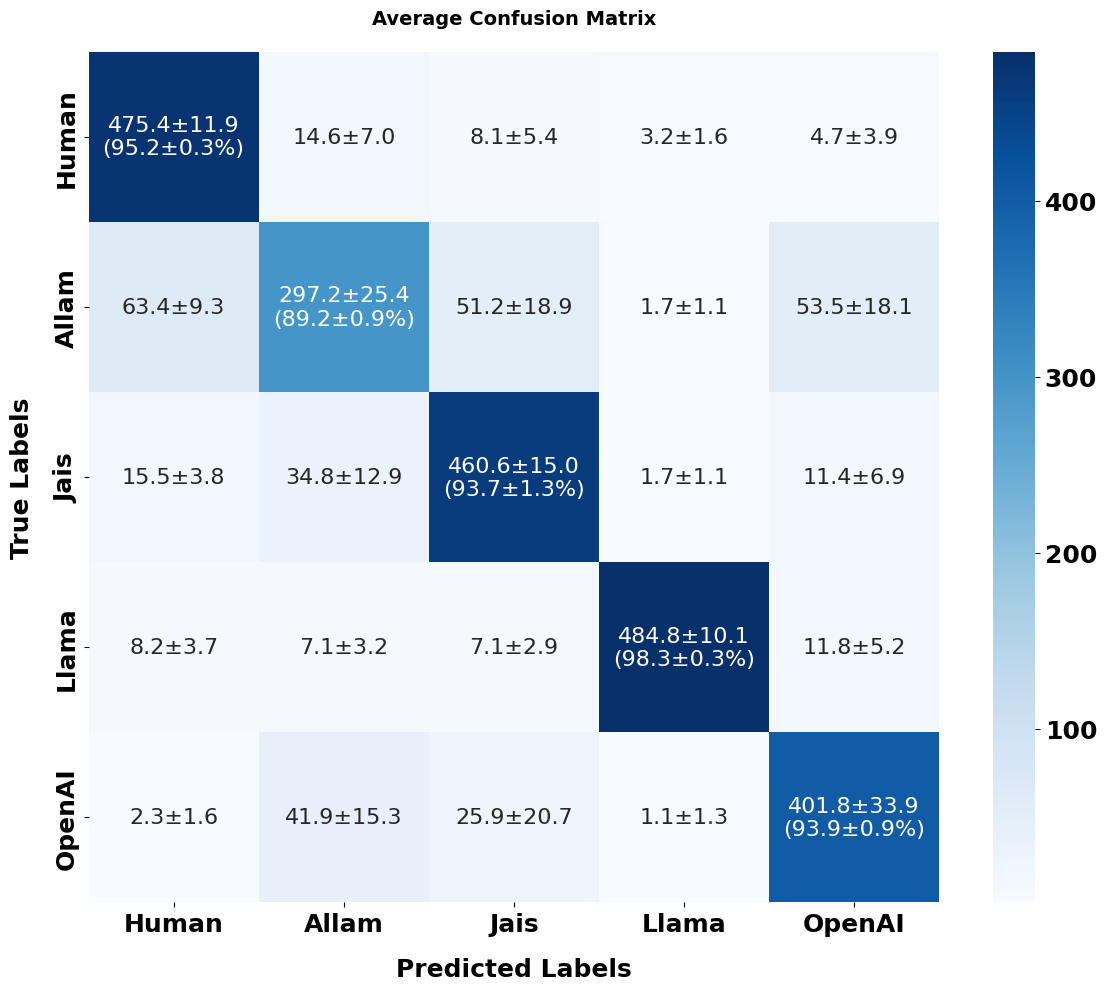


Confusion Matrix Summary:
Number of runs: 10
Overall accuracy: 85.17±1.59%

Per-Class Binary Accuracies (shown on diagonal):
  Human: 95.18±0.33%
  Allam: 89.22±0.91%
  Jais: 93.74±1.33%
  Llama: 98.32±0.35%
  OpenAI: 93.87±0.94%
Visualization generated from notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/multiclass_results.json


(array([[475.4,  14.6,   8.1,   3.2,   4.7],
        [ 63.4, 297.2,  51.2,   1.7,  53.5],
        [ 15.5,  34.8, 460.6,   1.7,  11.4],
        [  8.2,   7.1,   7.1, 484.8,  11.8],
        [  2.3,  41.9,  25.9,   1.1, 401.8]]),
 array([[11.91823999,  7.02693232,  5.38413307,  1.61932771,  3.94546153],
        [ 9.33571398, 25.35437722, 18.89620773,  1.05934991, 18.069311  ],
        [ 3.80788655, 12.87374589, 15.04216297,  1.05934991,  6.88315173],
        [ 3.67574633,  3.24722103,  2.8848262 , 10.141225  ,  5.20256347],
        [ 1.56702124, 15.25669252, 20.74420937,  1.28668394, 33.94047076]]))

In [10]:
def plot_confusion_matrix(results_file="notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/multiclass_results.json"):
    """Plot average confusion matrix with standard deviations across all runs."""
    
    # Load results
    if not os.path.exists(results_file):
        print(f"Results file {results_file} not found. Run experiments first.")
        return
    
    with open(results_file, 'r') as f:
        data = json.load(f)
    
    # Collect all confusion matrices
    confusion_matrices = []
    for run in data['runs']:
        if 'confusion_matrix' in run and 'error' not in run:
            confusion_matrices.append(np.array(run['confusion_matrix']))
    
    if not confusion_matrices:
        print("No confusion matrices found in results.")
        return
    
    # Calculate mean and std
    confmat_stack = np.stack(confusion_matrices)
    avg_confmat = np.mean(confmat_stack, axis=0)
    std_confmat = np.std(confmat_stack, axis=0, ddof=1) if len(confusion_matrices) > 1 else np.zeros_like(avg_confmat)
    
    # Set the style and font sizes
    sns.set_palette("husl")
    plt.rcParams['font.size'] = 18
    plt.rcParams['font.weight'] = 'bold'
    
    # Define labels
    labels = ['Human', 'Allam', 'Jais', 'Llama', 'OpenAI']
    
    # Create single figure (only the left matrix)
    plt.figure(figsize=(12, 10))
    
    if len(confusion_matrices) > 1:
        # Calculate per-class accuracy stats (consistent with table)
        all_per_class_accuracies = []
        for confmat in confusion_matrices:
            total_samples = confmat.sum()
            class_accuracies = []
            for i in range(len(labels)):
                tp = confmat[i, i]
                fp = confmat[:, i].sum() - tp
                fn = confmat[i, :].sum() - tp
                tn = total_samples - tp - fp - fn
                accuracy = (tp + tn) / total_samples * 100
                class_accuracies.append(accuracy)
            all_per_class_accuracies.append(class_accuracies)
        
        per_class_acc_means = np.mean(all_per_class_accuracies, axis=0)
        per_class_acc_stds = np.std(all_per_class_accuracies, axis=0, ddof=1)
        
        # Create annotations with mean ± std for counts and binary accuracy percentages
        annotations_mean = []
        for i in range(len(labels)):
            row_annotations = []
            for j in range(len(labels)):
                count_mean = avg_confmat[i, j]
                count_std = std_confmat[i, j]
                if i == j:  # Diagonal elements - show binary accuracy
                    acc_mean = per_class_acc_means[i]
                    acc_std = per_class_acc_stds[i]
                    annotation = f'{count_mean:.1f}±{count_std:.1f}\n({acc_mean:.1f}±{acc_std:.1f}%)'
                else:  # Off-diagonal elements - show count only
                    annotation = f'{count_mean:.1f}±{count_std:.1f}'
                row_annotations.append(annotation)
            annotations_mean.append(row_annotations)
        
        annotations_mean = np.array(annotations_mean)
        
        # Create heatmap for means
        sns.heatmap(avg_confmat, 
                    annot=annotations_mean,
                    fmt='',
                    cmap='Blues',
                    xticklabels=labels,
                    yticklabels=labels,
                    square=True,
                    annot_kws={'size': 16, 'weight': 'normal'})
        
        plt.title('Average Confusion Matrix', 
                  pad=20, size=14, weight='bold')
        
    else:
        # Single run - show simple confusion matrix
        # Calculate per-class accuracies for single run
        total_samples = avg_confmat.sum()
        per_class_acc_means = []
        for i in range(len(labels)):
            tp = avg_confmat[i, i]
            fp = avg_confmat[:, i].sum() - tp
            fn = avg_confmat[i, :].sum() - tp
            tn = total_samples - tp - fp - fn
            accuracy = (tp + tn) / total_samples * 100
            per_class_acc_means.append(accuracy)
        per_class_acc_stds = [0.0] * len(labels)
        
        # Create annotations with counts and binary accuracy percentages
        annotations = []
        for i in range(len(labels)):
            row_annotations = []
            for j in range(len(labels)):
                count = avg_confmat[i, j]
                if i == j:  # Diagonal elements - show binary accuracy
                    acc = per_class_acc_means[i]
                    annotation = f'{count:.0f}\n({acc:.1f}%)'
                else:  # Off-diagonal elements - show count only
                    annotation = f'{count:.0f}'
                row_annotations.append(annotation)
            annotations.append(row_annotations)
        
        annotations = np.array(annotations)
        
        # Create heatmap using seaborn
        sns.heatmap(avg_confmat, 
                    annot=annotations,
                    fmt='',
                    cmap='Blues',
                    xticklabels=labels,
                    yticklabels=labels,
                    square=True,
                    annot_kws={'size': 11, 'weight': 'normal'})
        
        plt.title('Multi-Class Confusion Matrix\n(Diagonal: Binary Accuracy %; Off-diagonal: Counts)', 
                  pad=20, size=16, weight='bold')
    
    plt.xlabel('Predicted Labels', labelpad=15, size=18, weight='bold')
    plt.ylabel('True Labels', labelpad=15, size=18, weight='bold')
    
    # Add overall statistics
    total = avg_confmat.sum()
    correct = np.trace(avg_confmat)
    overall_accuracy_mean = correct / total * 100
    
    # Calculate overall accuracy std across runs
    if len(confusion_matrices) > 1:
        overall_accuracies = [(np.trace(cm) / cm.sum() * 100) for cm in confusion_matrices]
        overall_accuracy_std = np.std(overall_accuracies, ddof=1)
    else:
        overall_accuracy_std = 0.0
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics (consistent with table)
    print(f"\nConfusion Matrix Summary:")
    print(f"Number of runs: {len(confusion_matrices)}")
    print(f"Overall accuracy: {overall_accuracy_mean:.2f}±{overall_accuracy_std:.2f}%")
    print(f"\nPer-Class Binary Accuracies (shown on diagonal):")
    for i, label in enumerate(labels):
        if len(confusion_matrices) > 1:
            print(f"  {label}: {per_class_acc_means[i]:.2f}±{per_class_acc_stds[i]:.2f}%")
        else:
            print(f"  {label}: {per_class_acc_means[i]:.2f}%")
    print(f"Visualization generated from {results_file}")
    
    return avg_confmat, std_confmat

# Generate confusion matrix plot
plot_confusion_matrix("notebooks/Arabic_experiments/ArabicSocialMediaDataset/multiple_runs/multiclass_results.json")